<a href="https://colab.research.google.com/github/juliasharmankina-web/Exploratory-Data-Analysis/blob/main/Exploratory_Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Checking and cleaning data
The `events.csv` table is linked to `products.csv` via the `product_id/id` column and to `countries.csv` via the `country_code/alpha-3` column.

###Events.csv

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/mate_academy/Final_project


# Uploading dataset
events_data = pd.read_csv("events.csv")
events_data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/mate_academy/Final_project


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# checking number of rows and columns in the table

print(events_data.shape)

(1330, 10)


In [ ]:
# checking information the table contains, data types, presence of missed values
events_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


Identified problems and anomalies:
- The table contains missing values in the **Country Code** and **Units Sold** columns.
- **Order Date** and **Ship Date** have an incorrect object format; they need to be converted to datetime.

In [ ]:
#checking amount of missing values in each column
print(events_data.isna().sum())


Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [ ]:
#checking share of the missed values:
print(events_data.isna().sum() / events_data.shape[0] * 100)
# the most missing value contains Country Code (6.165414), because this information isn't crutial we will just fill the empty rows with na


Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
#replacing missing values in the columns
events_data["Country Code"].fillna("na", inplace=True)
events_data["Units Sold"].fillna(0, inplace=True)


/tmp/ipykernel_5388/2359266320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  events_data["Country Code"].fillna("na", inplace=True)
/tmp/ipykernel_5388/2359266320.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
#checking for duplicates in data
duplicate_rows = events_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())
# --> 0

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1330, dtype: bool
0


In [ ]:
# changing the column names to unify format (lower case, snake case, absence of spaces at the beggining and at the end of the names)
events_data.columns = events_data.columns.str.lower().str.replace(" ", "_")
events_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,na,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# Convert the date column to datetime
events_data["order_date"] = pd.to_datetime(events_data["order_date"])
events_data["ship_date"] = pd.to_datetime(events_data["ship_date"])
events_data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


In [ ]:
events_data.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4944.754887,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,0.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2349.250000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4958.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2909.352258,217.323460,176.158873


###Products.csv

In [ ]:
# Changing work folder
%cd /content/drive/MyDrive/mate_academy/Final_project

# Uploading dataset
products_data = pd.read_csv("products.csv")


/content/drive/MyDrive/mate_academy/Final_project


In [ ]:
# checking information that table contains

products_data.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
# checking number of rows and columns in the table

print(products_data.shape)


(12, 2)


In [ ]:
products_data.info() # --> issues are absent (no missing values; data types are correct)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
# changing the data to the lower case to unify it and deleting the spaces at the end and at the beginning of the object cells
products_data["item_type"] = products_data["item_type"].str.lower().str.strip()

In [ ]:
# checking for duplicates

duplicate_rows = products_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum()) #--> 0

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool
0


###Countries.csv

In [ ]:
# Changing work folder
%cd /content/drive/MyDrive/mate_academy/Final_project

# Uploading dataset
countries_data = pd.read_csv("countries.csv")

/content/drive/MyDrive/mate_academy/Final_project


In [ ]:
# checking information that table contains
countries_data.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
# checking dtype, shape and missing values that table
countries_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
# checking number of rows and columns in the table
print(countries_data.shape)


(249, 5)


In [ ]:
# changing the data to the lower case to unify it and deleting the spaces at the end and at the beginning of the data
col = countries_data.columns
countries_data[col] = countries_data[col].apply(lambda x: x.str.lower().str.strip())


In [ ]:
print(countries_data.isna().sum())
# --> there are a few absent values in alpha-2, region and sub-region

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [ ]:
# checking percentage for missing values in the table

print(countries_data.isna().sum() / countries_data.shape[0] * 100)
# --> for all 3 columns the share of missed values is 0.401606 (more than 0.004%) which means we cannot delete them

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [ ]:
countries_data.loc[153, "alpha-2"] = "na" # filling in the missed value in this row ("NA" is the official 2-letter country code for Namibia)
countries_data.loc[8, "region":"sub-region"] = "antarctica" # filling in the rest missing values

In [ ]:
# checking for missing values
countries_data.isna().sum() # --> no missing values

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


In [ ]:
# checking for duplicates
duplicate_rows = countries_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum()) # --> 0

0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 249, dtype: bool
0


# Merging the tables

In [ ]:
# Convert country_code in events_data to lowercase and rename to alpha-3 to match countries_data
events_data['country_code'] = events_data['country_code'].str.lower()
events_data.rename(columns={"country_code": "alpha-3"}, inplace=True)

# joining events and countries tables
event_country_join = pd.merge(events_data, countries_data, on="alpha-3", how="left")

# changing the column name so it is possible to join the tables
products_data.rename(columns={"id": "product_id"}, inplace=True)

# adding the products table
final_data = pd.merge(event_country_join, products_data, on="product_id", how="left")

# renaming name to country_name
final_data.rename(columns={"name": "country_name"}, inplace=True)

# checking final data information, dtype, and missing values
display(final_data.head())
display(final_data.info())

,order_id,order_date,ship_date,order_priority,alpha-3,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,alpha-2,region,sub-region,item_type
0,100640618,2014-10-08,2014-10-18,M,nor,2103,Online,650.0,205.70,117.11,norway,no,europe,northern europe,cereal
1,100983083,2016-08-11,2016-08-11,C,srb,2103,Offline,1993.0,205.70,117.11,serbia,rs,europe,southern europe,cereal
2,101025998,2014-07-18,2014-08-11,M,na,7940,Online,4693.0,668.27,502.54,NaN,NaN,NaN,NaN,household
3,102230632,2017-05-13,2017-06-13,L,mne,2455,Online,1171.0,109.28,35.84,montenegro,me,europe,southern europe,clothes
4,103435266,2012-08-11,2012-09-18,H,srb,1270,Offline,7648.0,47.45,31.79,serbia,rs,europe,southern europe,beverages


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   alpha-3         1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
 10  country_name    1248 non-null   object        
 11  alpha-2         1248 non-null   object        
 12  region          1248 non-null   object        
 13  sub-region      1248 non-null   object        
 14  item_type       1330 non-null   object        
dtypes: d

None

In [ ]:
# checking for duplicates
duplicate_rows_sales = final_data.duplicated()
duplicate_rows_sales.sum() # --> 0

np.int64(0)

In [ ]:
final_data.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4944.754887,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,0.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2349.250000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4958.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2909.352258,217.323460,176.158873


#Data analysis and visualization

Start with key company performance metrics: total number of orders, total profit, total number of countries covered, etc. (invent other metrics).

In [ ]:
# calculating sales metrics
final_data["revenue"] = final_data["units_sold"] * final_data["unit_price"]
final_data["total_cost"] = final_data["units_sold"] * final_data["unit_cost"]
final_data["profit"] = final_data["revenue"] - final_data["total_cost"]

print(final_data.head())

    order_id order_date  ship_date order_priority alpha-3  product_id  \
0  100640618 2014-10-08 2014-10-18              M     nor        2103   
1  100983083 2016-08-11 2016-08-11              C     srb        2103   
2  101025998 2014-07-18 2014-08-11              M      na        7940   
3  102230632 2017-05-13 2017-06-13              L     mne        2455   
4  103435266 2012-08-11 2012-09-18              H     srb        1270   

  sales_channel  units_sold  unit_price  unit_cost country_name alpha-2  \
0        Online       650.0      205.70     117.11       norway      no   
1       Offline      1993.0      205.70     117.11       serbia      rs   
2        Online      4693.0      668.27     502.54          NaN     NaN   
3        Online      1171.0      109.28      35.84   montenegro      me   
4       Offline      7648.0       47.45      31.79       serbia      rs   

   region       sub-region  item_type     revenue  total_cost     profit  
0  europe  northern europe     cere

In [ ]:
#findin total orders and amount of units
total_orders = final_data['order_id'].nunique()
sum_of_units = final_data['units_sold'].sum()
print(f"Total orders amount: {total_orders}")
print(f"Sum of units sold: {sum_of_units}")

Total orders amount: 1330
Sum of units sold: 6576524.0


In [ ]:
# Total profit, revenue, total_cost
revenue = (final_data['units_sold']* final_data['unit_price']).sum()
print(f"Total revenue: {revenue}")
total_cost= (final_data['units_sold']* final_data['unit_cost']).sum()
print(f"Total cost: {total_cost}")
profit = revenue - total_cost
print(f"Total profit: {profit}")


Total revenue: 1702129408.21
Total cost: 1200694949.2099998
Total profit: 501434459.00000024


In [ ]:
# Total amount of unique countries
total_countries = final_data["country_name"].nunique()
print(f"Total amount of unique countries: {total_countries}")

Total amount of unique countries: 45


In [ ]:
# Orders by category
orders_by_category = final_data.groupby("item_type")["order_id"].nunique()
print(orders_by_category)

item_type
baby food          112
beverages          121
cereal             103
clothes            105
cosmetics          114
fruits             112
household           97
meat               111
office supplies    123
personal care      115
snacks             103
vegetables         114
Name: order_id, dtype: int64


In [ ]:
#orders by region
orders_by_region = final_data.groupby("region")["order_id"].nunique()
print(orders_by_region)

region
asia        82
europe    1166
Name: order_id, dtype: int64


In [ ]:
# Profit by categories
profit_by_category = final_data.groupby("item_type")["profit"].sum()
print(profit_by_category)

item_type
baby food          53940997.16
beverages           9601662.78
cereal             41255034.15
clothes            43431314.40
cosmetics          92723306.17
fruits              1425929.52
household          72962466.77
meat               30337736.00
office supplies    77977176.25
personal care      13975410.68
snacks             27027422.40
vegetables         36776002.72
Name: profit, dtype: float64


In [ ]:
# Calculating the difference between the order date and shipping date
time_diff = final_data["ship_date"] - final_data["order_date"]
final_data["time_diff"] = time_diff.dt.days
print(time_diff)

0      10 days
1       0 days
2      24 days
3      31 days
4      38 days
         ...  
1325    3 days
1326   28 days
1327    2 days
1328   18 days
1329   36 days
Length: 1330, dtype: timedelta64[ns]


#Visual Analysis

/tmp/ipykernel_1626/1056548423.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unit_sold_by_category.index, y=unit_sold_by_category.values, palette="inferno")


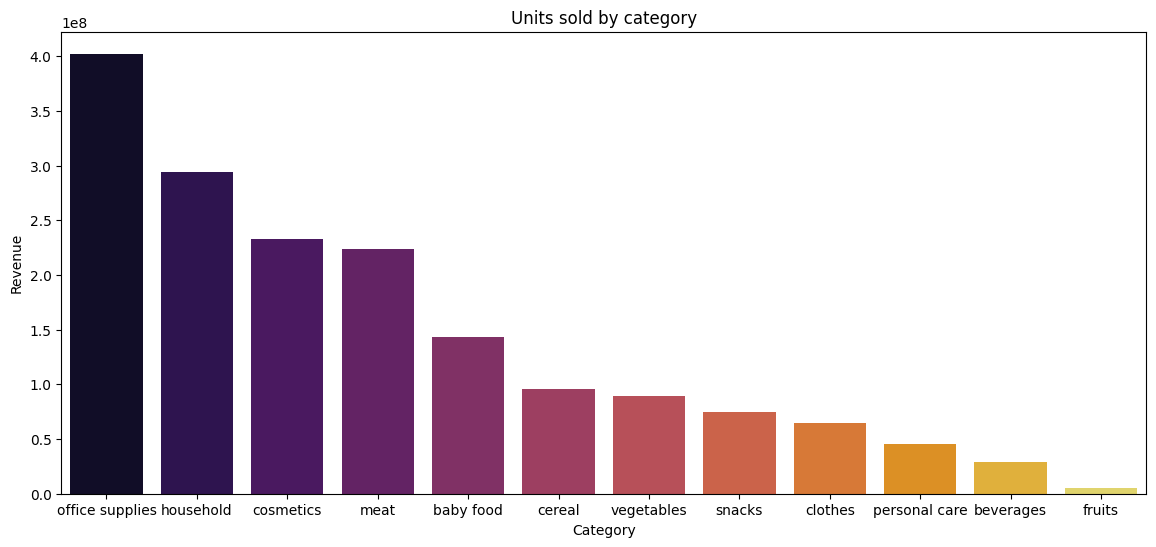

In [ ]:
# Bar Chart:Units sold by category
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 6))
unit_sold_by_category = final_data.groupby("item_type")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=unit_sold_by_category.index, y=unit_sold_by_category.values, palette="inferno")
plt.title("Units sold by category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

/tmp/ipykernel_1626/832850589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_category.index, y=profit_by_category.values, palette="inferno")


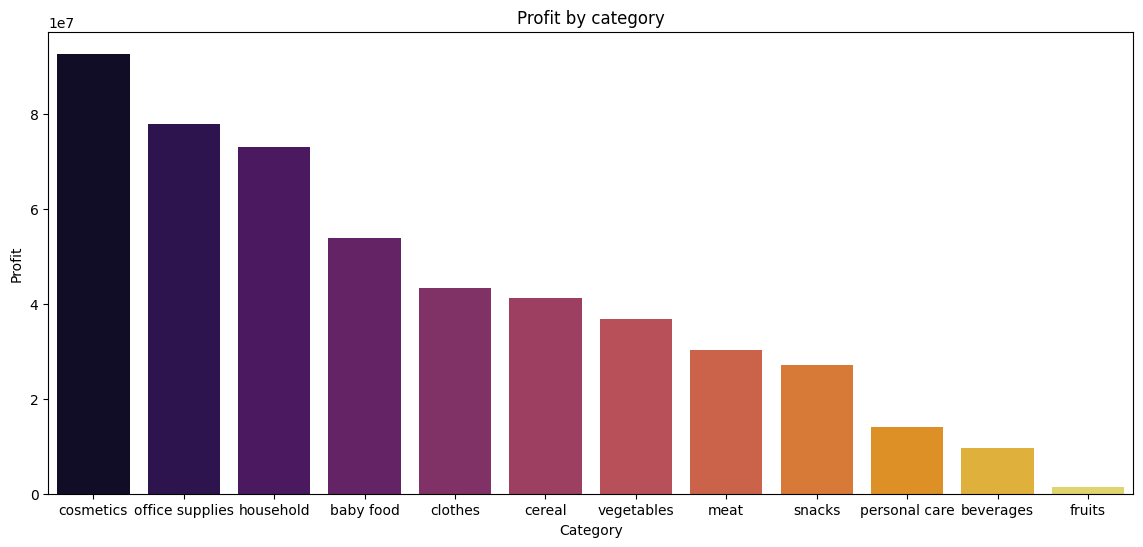

In [ ]:
# Bar Chart:Profit by category
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 6))
profit_by_category = final_data.groupby("item_type")["profit"].sum().sort_values(ascending=False)
sns.barplot(x=profit_by_category.index, y=profit_by_category.values, palette="inferno")
plt.title("Profit by category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

In [ ]:
final_data['sales_channel'] = final_data['sales_channel'].str.lower()
print(final_data['sales_channel'].unique())

['online' 'offline']


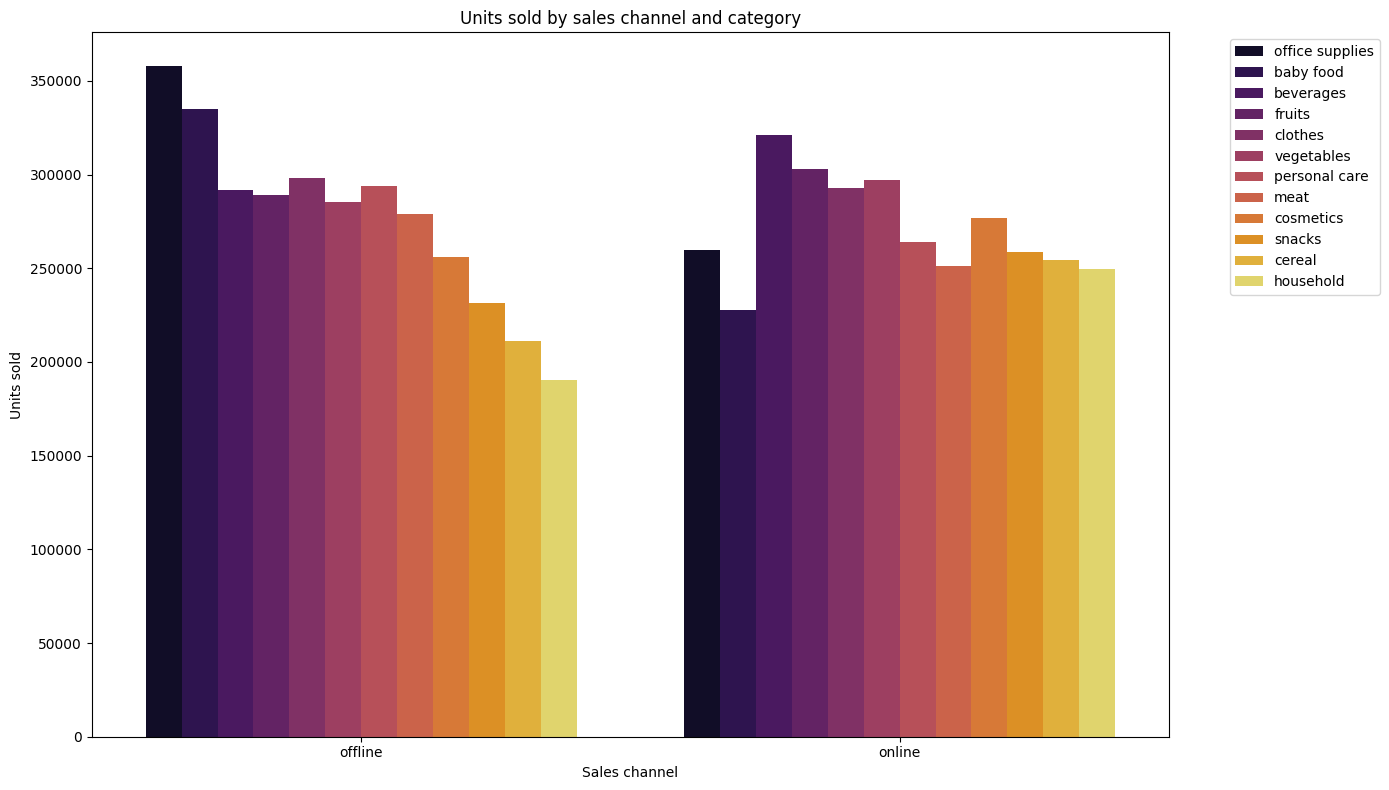

In [ ]:
# Units sold by sales channel and category
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
# Group by sales_channel and item_type, then sum units_sold and reset index to create columns for plotting
unit_sold_by_channel_category = final_data.groupby(["sales_channel", "item_type"])["units_sold"].sum().reset_index().sort_values(by="units_sold", ascending=False)
sns.barplot(x="sales_channel", y="units_sold", hue="item_type", data=unit_sold_by_channel_category, palette="inferno", errorbar=None)
plt.title("Units sold by sales channel and category")
plt.xlabel("Sales channel")
plt.ylabel("Units sold")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position to avoid overlapping
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

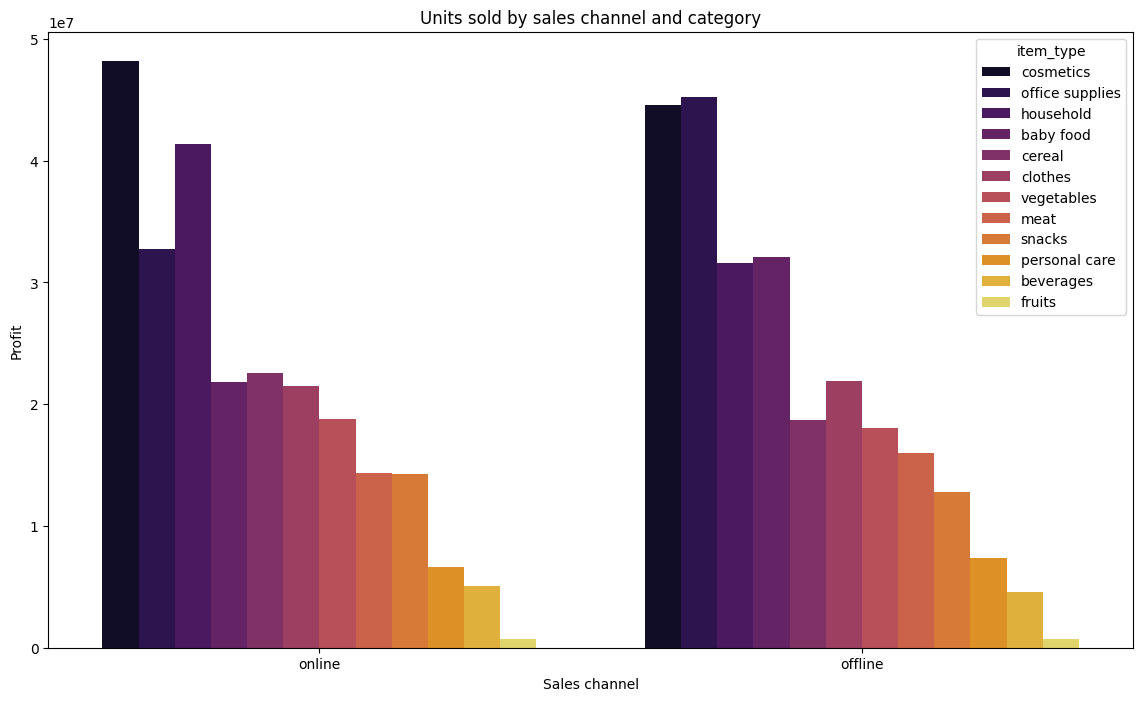

In [ ]:
#Profit by sales channel and category
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
profit_by_channel_category = final_data.groupby(["sales_channel", "item_type"])["profit"].sum().reset_index().sort_values(by="profit", ascending=False)
sns.barplot(x="sales_channel", y="profit", hue="item_type", data=profit_by_channel_category, palette="inferno", errorbar=None)
plt.title("Units sold by sales channel and category")
plt.xlabel("Sales channel")
plt.ylabel("Profit")
plt.show()

/tmp/ipykernel_1626/2221234685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_channel_data.index, y=sales_channel_data.values, palette="inferno")


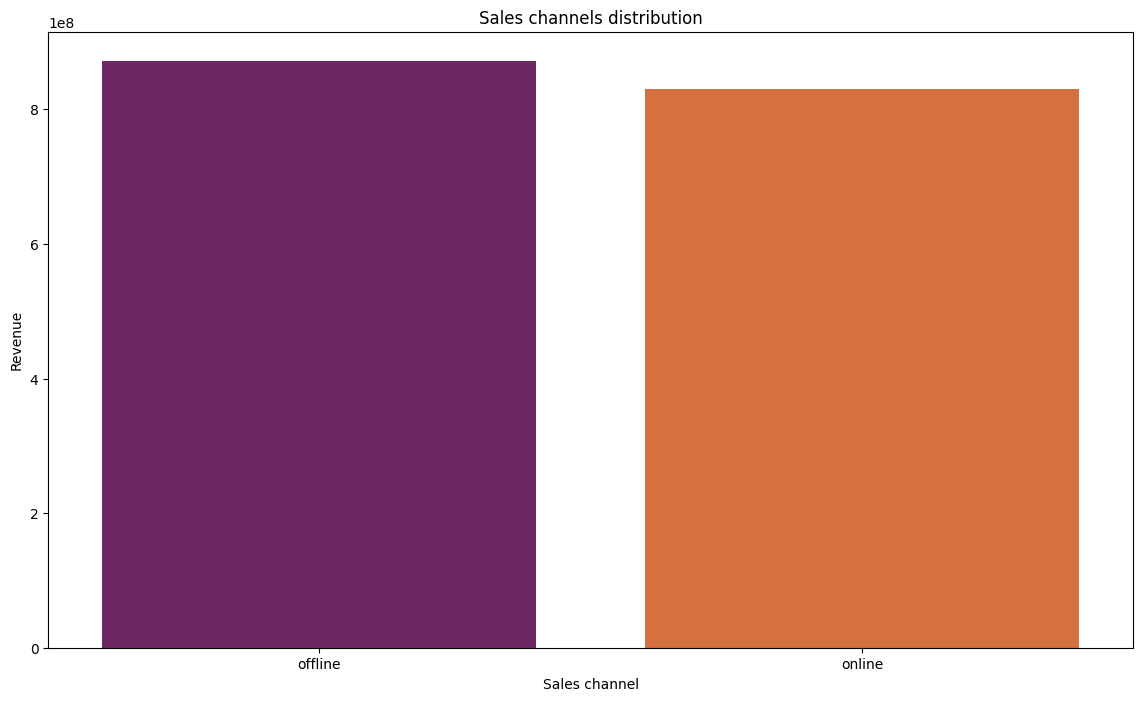

In [ ]:
#sales channels distribution
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
sales_channel_data = final_data.groupby("sales_channel")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=sales_channel_data.index, y=sales_channel_data.values, palette="inferno")
plt.title("Sales channels distribution")
plt.xlabel("Sales channel")
plt.ylabel("Revenue")
plt.show()

/tmp/ipykernel_1626/40385851.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular_categories_data.index, y=popular_categories_data.values, palette="inferno")


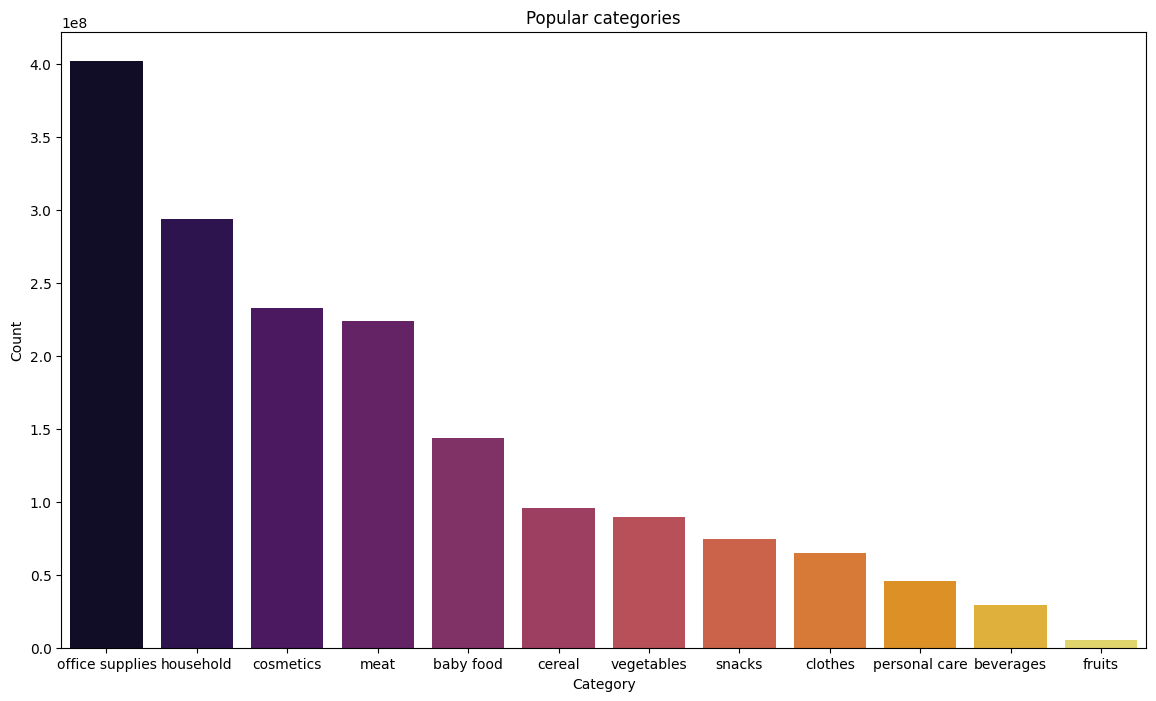

In [ ]:
#bar chart:Popular categories
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
popular_categories_data = final_data.groupby("item_type")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=popular_categories_data.index, y=popular_categories_data.values, palette="inferno")
plt.title("Popular categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_1626/2972987407.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette="inferno")


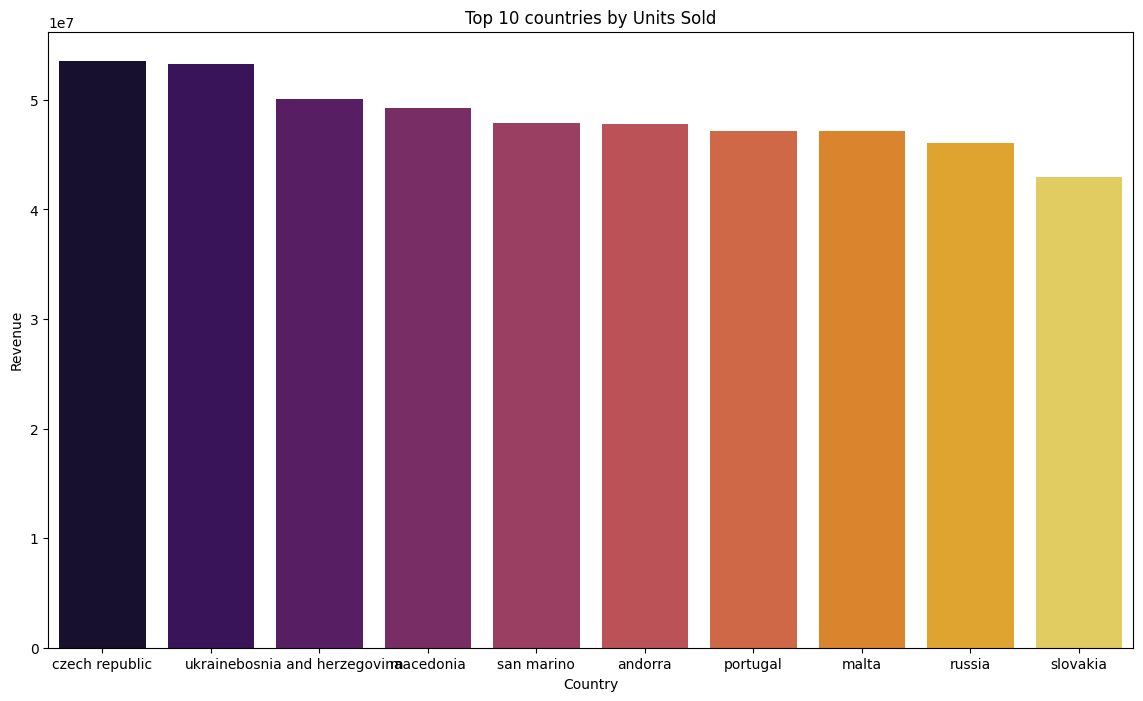

In [ ]:
# Top 10 countries by Revenue
top_10_countries = final_data.groupby("country_name")["revenue"].sum().sort_values(ascending=False).head(10)
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette="inferno")
plt.title("Top 10 countries by Units Sold")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

/tmp/ipykernel_1626/2979974886.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette="inferno")


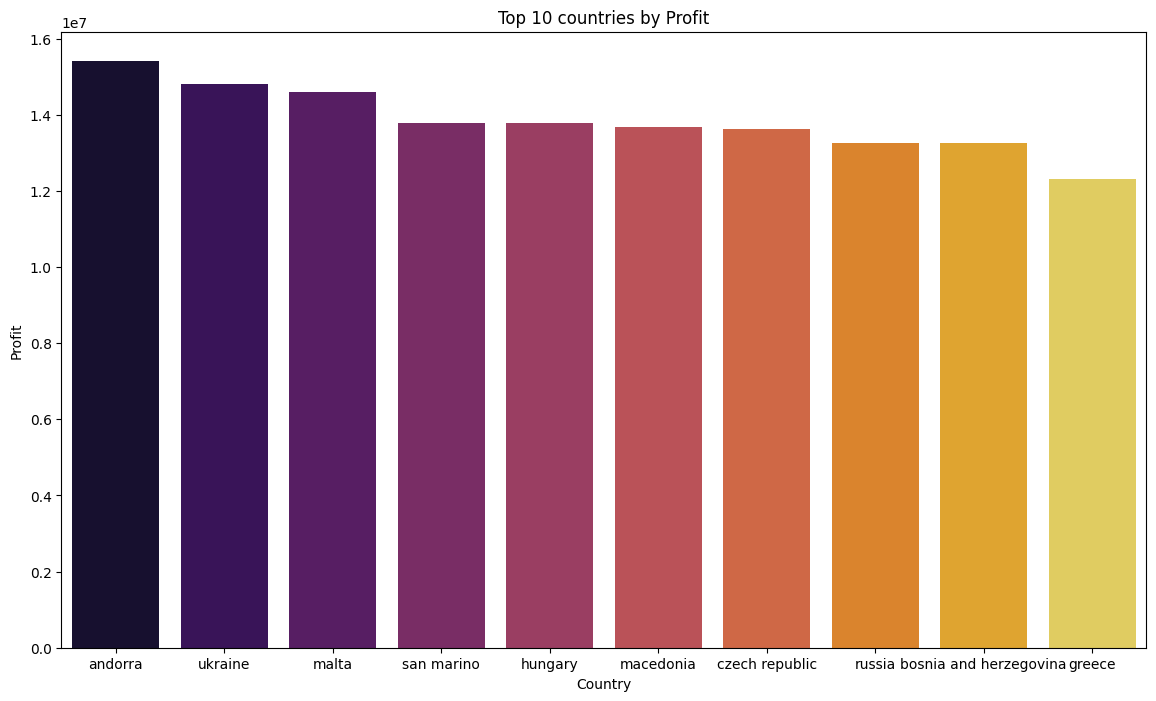

In [ ]:
# Top 10 countries by Profit
top_10_countries = final_data.groupby("country_name")["profit"].sum().sort_values(ascending=False).head(10)
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette="inferno")
plt.title("Top 10 countries by Profit")
plt.xlabel("Country")
plt.ylabel("Profit")
plt.show()

#Order shipping period



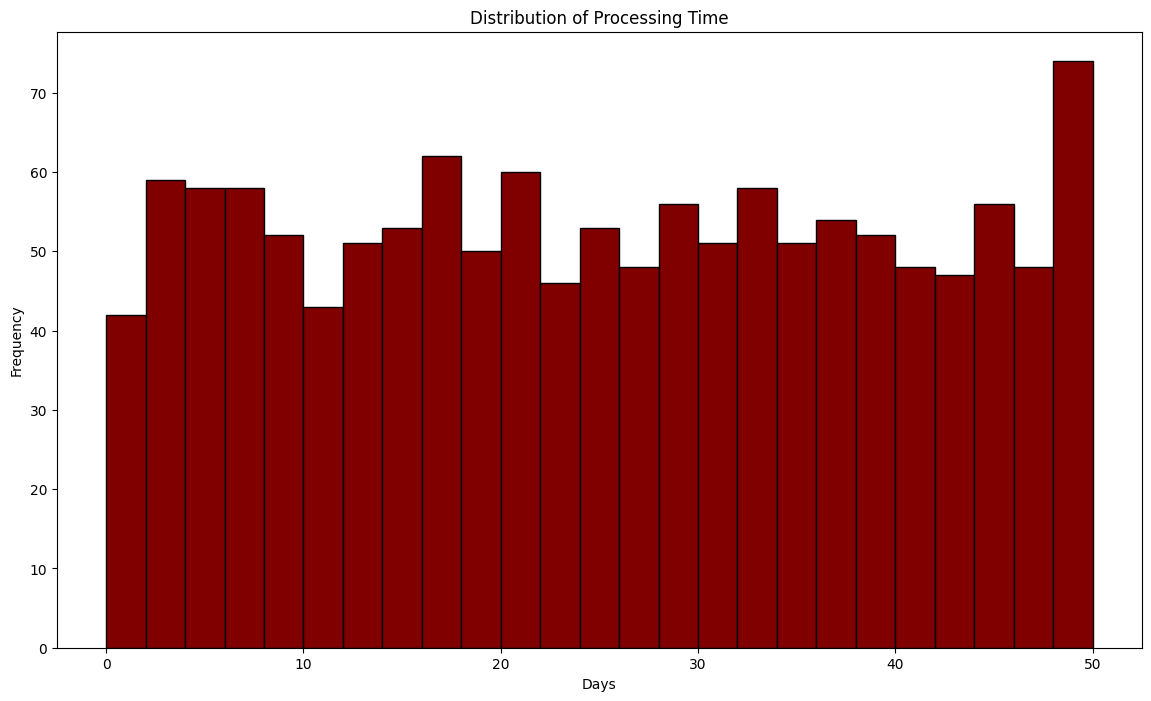

In [ ]:
#Time interval between order_date and ship_date
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
plt.hist(final_data["time_diff"], bins=25, color="maroon", edgecolor="black")
plt.title("Distribution of Processing Time")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_1626/3590037956.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_days_category.index, y=order_days_category.values, palette="inferno")


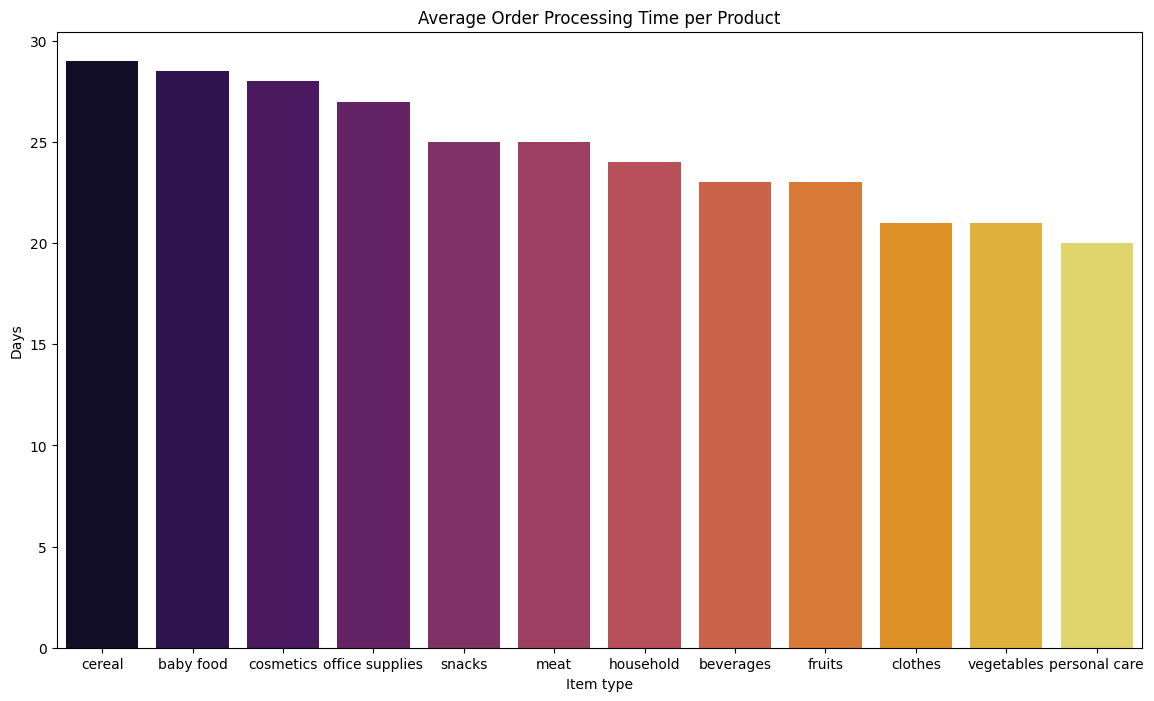

In [ ]:
# Ship days by item type
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
order_days_category = final_data.groupby("item_type")["time_diff"].median().sort_values(ascending=False)
sns.barplot(x=order_days_category.index, y=order_days_category.values, palette="inferno")
plt.title("Average Order Processing Time per Product")
plt.xlabel("Item type")
plt.ylabel("Days")
plt.show()

/tmp/ipykernel_1626/3634010741.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_days_country.index, y=order_days_country.values, palette="inferno")


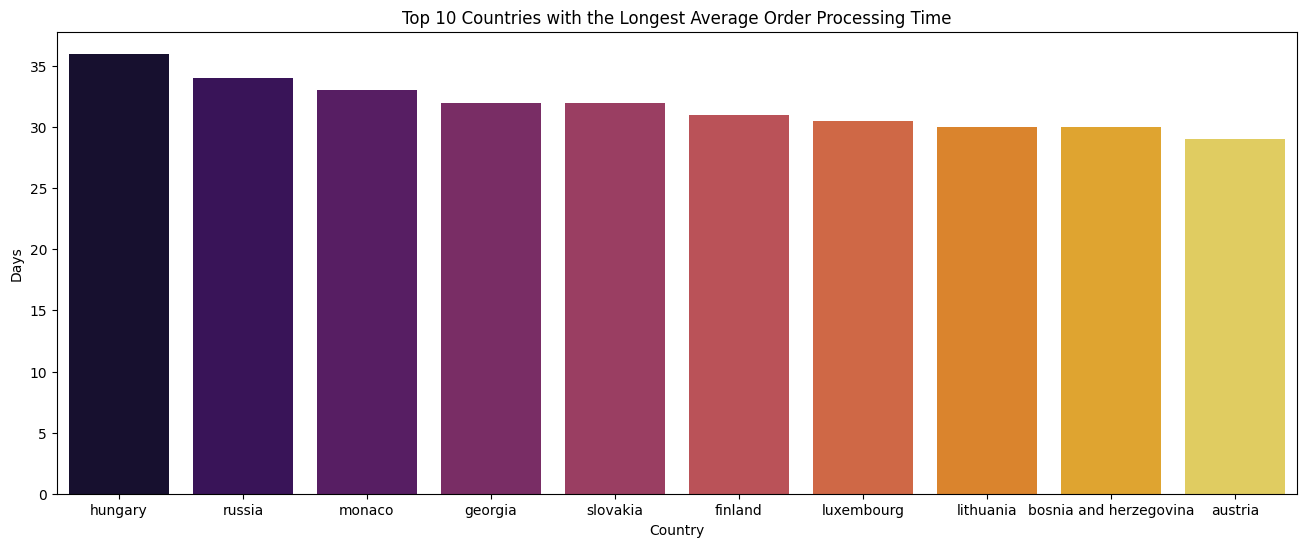

In [ ]:
#Shipping days by countries
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(16, 6))
order_days_country = final_data.groupby("country_name")["time_diff"].median().sort_values(ascending=False).head(10)
sns.barplot(x=order_days_country.index, y=order_days_country.values, palette="inferno")
plt.title("Top 10 Countries with the Longest Average Order Processing Time")
plt.xlabel("Country")
plt.ylabel("Days")
plt.show()

/tmp/ipykernel_1626/343801820.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_days_country.index, y=order_days_country.values, palette="inferno")


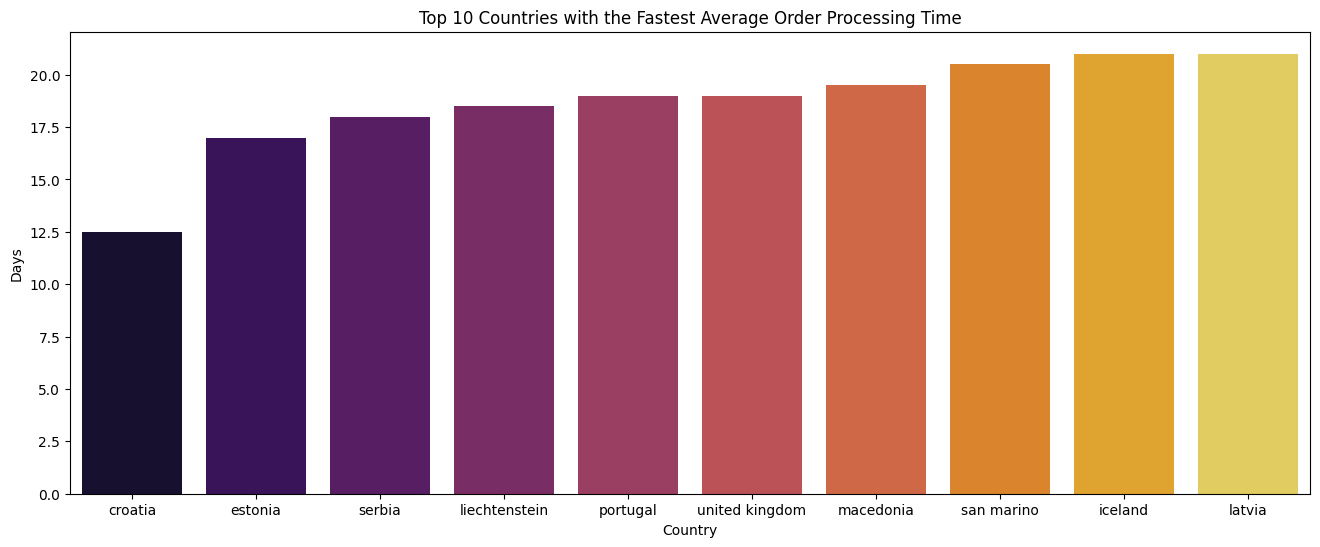

In [ ]:
#Shipping days by countries
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(16, 6))
order_days_country = final_data.groupby("country_name")["time_diff"].median().sort_values(ascending=True).head(10)
sns.barplot(x=order_days_country.index, y=order_days_country.values, palette="inferno")
plt.title("Top 10 Countries with the Fastest Average Order Processing Time")
plt.xlabel("Country")
plt.ylabel("Days")
plt.show()

/tmp/ipykernel_1626/2706578582.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_days_region.index, y=order_days_region.values, palette="inferno")


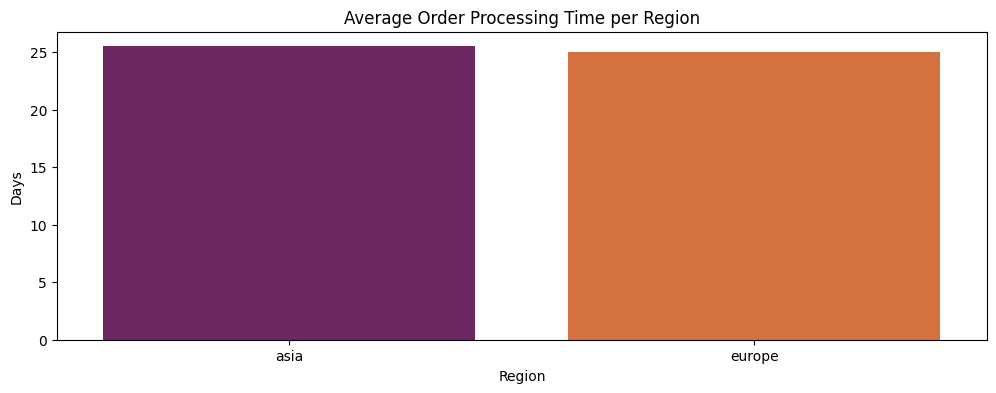

In [ ]:
#shipping days by regions
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(12, 4))
order_days_region= final_data.groupby("region")["time_diff"].median().sort_values(ascending=False)
sns.barplot(x=order_days_region.index, y=order_days_region.values, palette="inferno")
plt.title("Average Order Processing Time per Region")
plt.xlabel("Region")
plt.ylabel("Days")
plt.show()


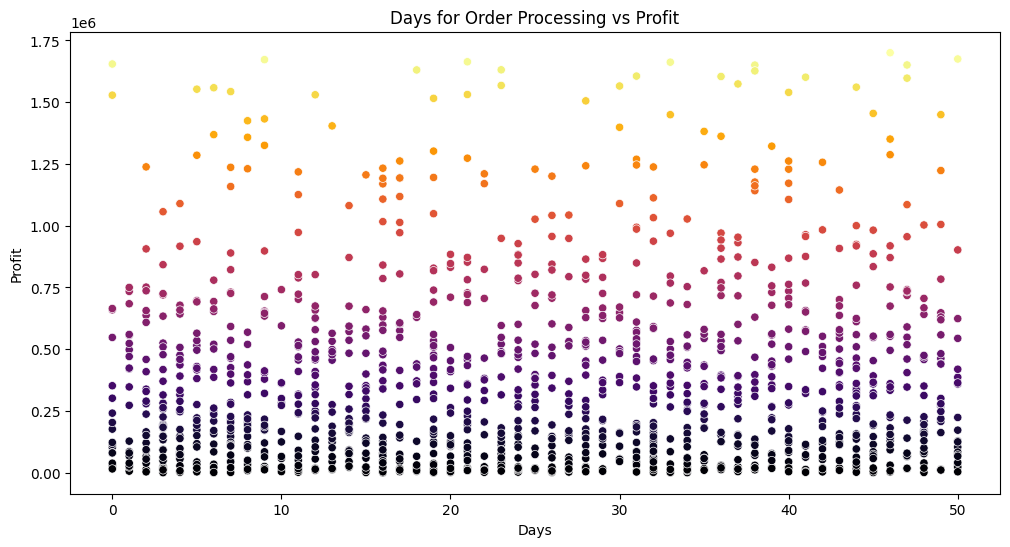

In [ ]:
#Order proccessing and profit
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(12, 6))
sns.scatterplot(data=final_data, x="time_diff", y="profit", palette="inferno", hue="profit",  legend=False, sizes=(20, 200))
plt.title("Days for Order Processing vs Profit")
plt.xlabel("Days")
plt.ylabel("Profit")
plt.show()


/tmp/ipykernel_1626/3759503820.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=final_data, x="time_diff", y="profit", palette="inferno", legend=False)


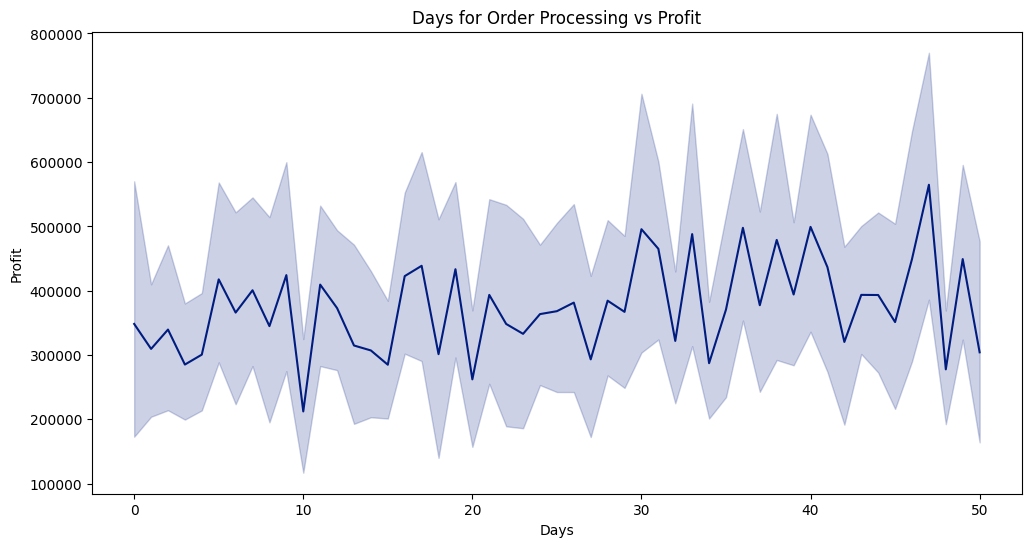

In [ ]:
#Order proccessing and profit
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(12, 6))
sns.lineplot(data=final_data, x="time_diff", y="profit", palette="inferno", legend=False)
plt.title("Days for Order Processing vs Profit")
plt.xlabel("Days")
plt.ylabel("Profit")
plt.show()

#Sales Dynamics

In [ ]:
# extracting the year and a month from a date for creating a readable dynamic chart
final_data["year_month"] = final_data["order_date"].dt.to_period('M')

# converting the Period data type to the datetime type so the chart can be created
final_data["year_month"] = final_data["year_month"].dt.to_timestamp()

/tmp/ipykernel_1626/635090639.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_for_last_2_years["year_month"] = data_for_last_2_years["order_date"].dt.to_period('M')
/tmp/ipykernel_1626/635090639.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_for_last_2_years["year_month"] = data_for_last_2_years["year_month"].dt.to_timestamp()


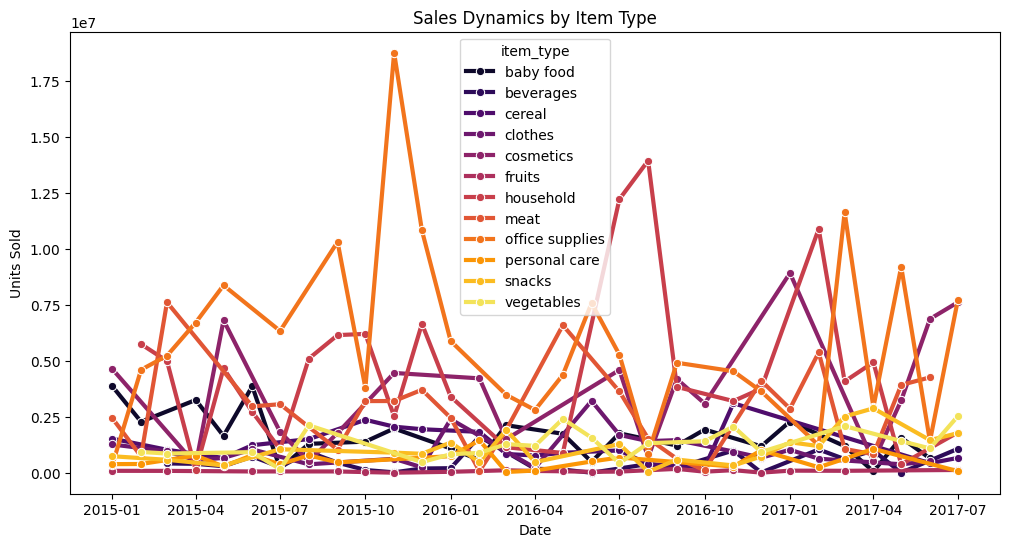

In [ ]:
# sales dynamic by item type for last 2 years
data_for_last_2_years = final_data[final_data["order_date"] >= "2015-01-01"] # Adjusted date to ensure data is present
# Ensure 'year_month' is present in the filtered DataFrame
data_for_last_2_years["year_month"] = data_for_last_2_years["order_date"].dt.to_period('M')
data_for_last_2_years["year_month"] = data_for_last_2_years["year_month"].dt.to_timestamp()
time_series_data_qty = (data_for_last_2_years.groupby(["item_type", "year_month"])["revenue"].sum().reset_index())
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(12, 6))
sns.lineplot(data=time_series_data_qty, x="year_month", y="revenue", hue="item_type", palette="inferno", linewidth=3, marker="o")
plt.title("Sales Dynamics by Item Type")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

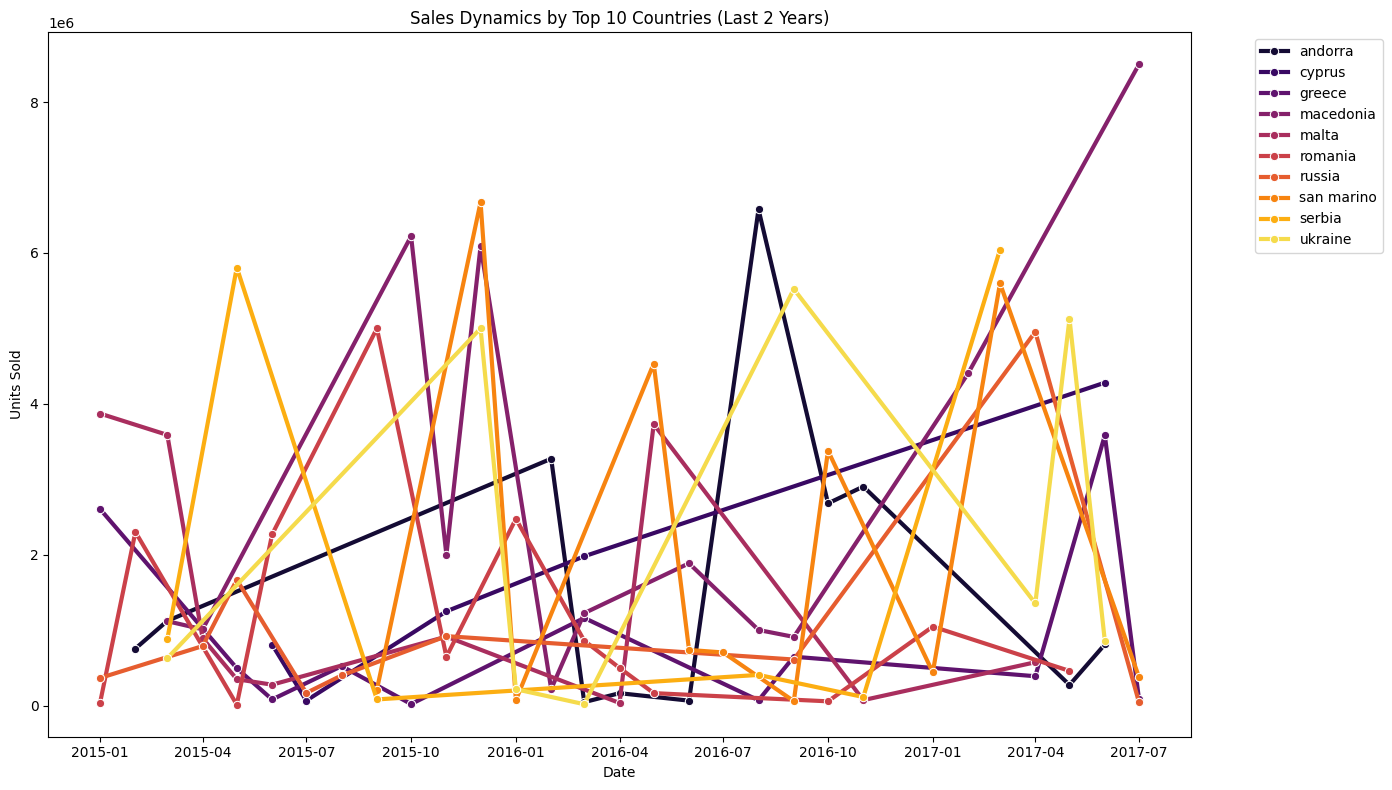

In [ ]:
# Calculate total units sold per country from the entire dataset to identify overall top countries
total_units_by_country = final_data.groupby("country_name")["units_sold"].sum().sort_values(ascending=False)

# Get the names of the top 10 countries
top_10_country_names = total_units_by_country.head(10).index

# Filter the 'data_for_last_2_years' DataFrame to include only these top 10 countries
data_for_top_10_countries_last_2_years = data_for_last_2_years[data_for_last_2_years["country_name"].isin(top_10_country_names)]

# Group the filtered data by country_name and year_month for sales dynamics
time_series_data_qty = (data_for_top_10_countries_last_2_years.groupby(["country_name", "year_month"])["revenue"].sum().reset_index())

plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(14, 8))
sns.lineplot(data=time_series_data_qty, x="year_month", y="revenue", hue="country_name", palette="inferno", linewidth=3,marker="o")
plt.title("Sales Dynamics by Top 10 Countries (Last 2 Years)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position to avoid overlapping
plt.tight_layout()
plt.show()

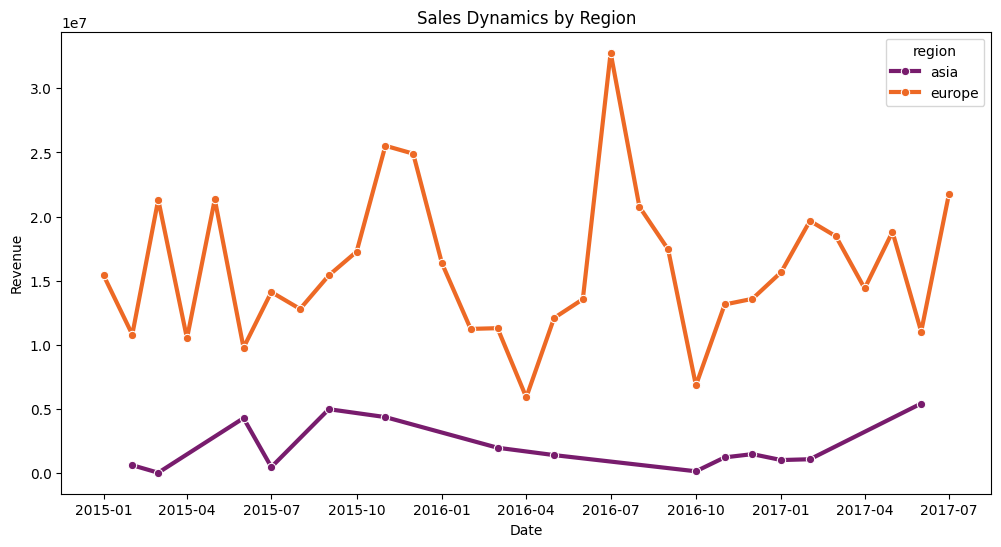

In [ ]:
# sales dynamic by region for last 2 years
time_series_data_qty = (data_for_last_2_years.groupby(["region", "year_month"])["revenue"].sum().reset_index())
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(12, 6))
sns.lineplot(data=time_series_data_qty, x="year_month", y="revenue", hue="region", palette="inferno", linewidth=3, marker="o")
plt.title("Sales Dynamics by Region")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

#Weekday analysis

In [ ]:
# extracting the day of week from the date
final_data["week_day"] = final_data["order_date"].dt.day_name()

sales_per_week_day = final_data.groupby("week_day")["revenue"].sum().reset_index()

# sorting the grouped result by the day of week
sales_per_week_day["day_number"] = [5, 1, 6, 7, 4, 2, 3]
sales_per_week_day = sales_per_week_day.sort_values(by="day_number")

#checking the changes
sales_per_week_day

,week_day,revenue,day_number
1,Monday,2.754685e+08,1
5,Tuesday,2.135239e+08,2
6,Wednesday,2.612157e+08,3
4,Thursday,2.149222e+08,4
0,Friday,2.638070e+08,5
2,Saturday,2.336411e+08,6
3,Sunday,2.395510e+08,7


/tmp/ipykernel_1626/3850720875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_per_week_day["week_day"], y=sales_per_week_day["revenue"], palette="inferno")


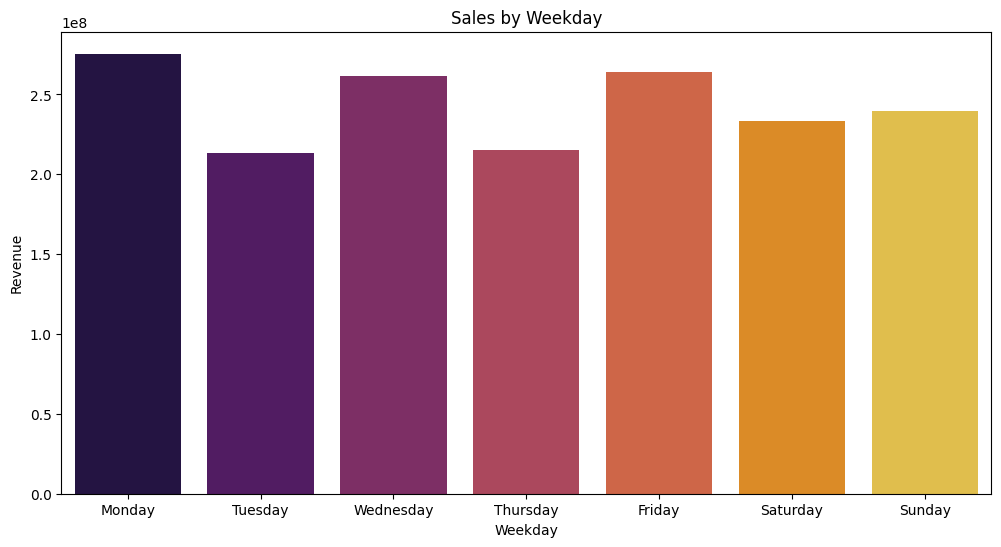

In [ ]:
#sales by weekday
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(12,6))
sns.barplot(x=sales_per_week_day["week_day"], y=sales_per_week_day["revenue"], palette="inferno")
plt.title("Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.show()

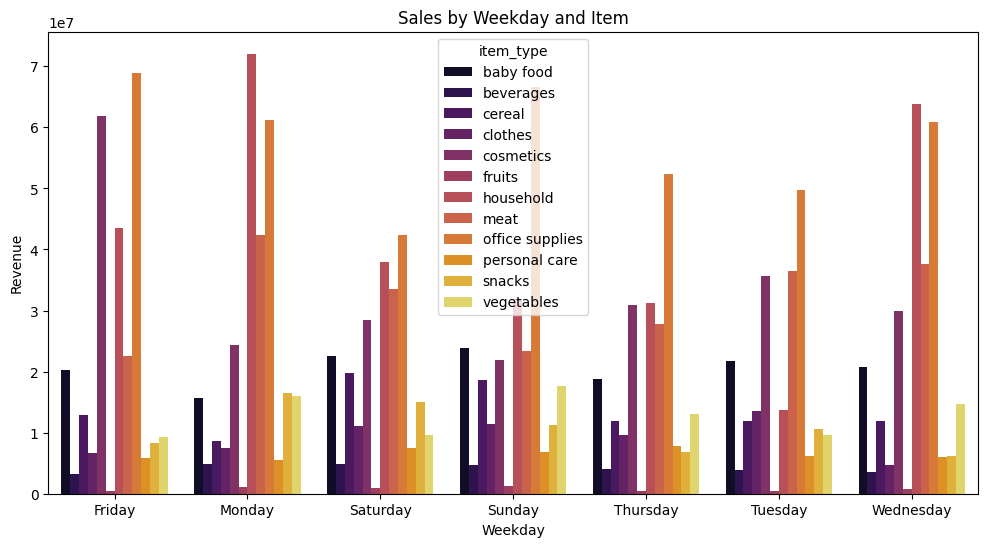

In [ ]:
#sales weekday by item
plt.style.use("seaborn-v0_8-dark-palette")
plt.figure(figsize=(12,6))
sales_per_week_day_item = final_data.groupby(["week_day", "item_type"])["revenue"].sum().reset_index()
sns.barplot(x="week_day", y="revenue", hue="item_type", data=sales_per_week_day_item, palette="inferno")
plt.title("Sales by Weekday and Item")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.show()

#Reporting

###General indicators

Total revenue: 1702129408.21

Total profit: 501434459.0

Total cost: 1200694949.21

Total number of orders: 1330

Number of units sold: 6576524.0

Number of countries covered: 45

###Geographical expansion and markets

The company operates in two regions:
- Europe
- Asia

Covers 45 countries.

Most orders are placed in European countries: 1166

Only 82 orders have been made in Asian countries so far.


Most popular countries by revenue:
Czech Republic, Ukraine, Bosnia and Herzegovina, Macedonia, San Marino, Andorra, Portugal, Malta, Russia, and Slovakia.

Conclusion:

Europe is the main market, generating most of the revenue. Asian countries are weakly represented, but the company has the potential for scaling and entering new markets in other sub-regions.

Компанія працює у двох регіонах:
- Європа
- Азія

Охоплює 45 країн.

Найбільше замовлень роблять у країнах Європи: 1166

У країнах Азії було зроблено тільки 82 замовлення за весь час.


Найпопулярніші країни за доходом:
Чехія, Україна, Босня та Герцеговина, Македонія, Сан Марино, Андора, Португалія, Мальта, Росія і Словакія.

Висновок:

Європа є основним ринком, що приносить більшу частину доходу. Країни Азії представлені слабо, але компанія має потенціал для масштабування та вихід на нові ринки в інших суб-регіонах.


###Operational efficiency (Logistics)

On average, delivery time across countries is 25 days.

The largest share of orders is delivered in 50 days.

The longest delivery times are to the Czech Republic and Russia (approximately 35 days). If these markets are target markets, the business loses competitiveness. The reason may be customs procedures, lack of local warehouses, or complex routes.

The fastest deliveries are to Estonia and Latvia (12-15 days). This indicates that the logistics model can work quickly.

Conclusion: Most likely, the warehouse or main distribution center is located in the Baltic region. The further the country is from the Baltics (or the more complex the border), the worse the performance.

###Economic consequences for the business

- Frozen capital: Goods that travel for 50 days are money that is not working. This worsens the Cash Conversion Cycle metric.

- LTV (Lifetime Value): It is unlikely that a customer who waited 50 days will return for a repeat purchase. The cost of acquiring a new customer (CAC) will increase because "old" customers do not become loyal.

- Logistics costs: Long delivery often means more intermediate storage stages, which increases the cost of operations.

Business recommendations:

- Review warehouse strategy: If the Czech Republic is an important market, consider opening a fulfillment center closer to Central Europe.

- Last-mile optimization: It is necessary to analyze at what stage the delay of up to 50 days occurs (customs, main transportation, or courier service within the country).

- Expectation management: Until logistics are corrected, marketing communications should indicate realistic timelines to avoid losing reputation.

###Analysis of product categories and sales channels

- Profit leaders: Cosmetics and Office Supplies categories are the most marginal. Despite not always having the largest sales volume in units, they generate the bulk of net profit.
- Outsiders: The Fruits category has the lowest indicators for both revenue and profit. This may be due to the low cost per unit of goods or high storage costs.

Strategy: If a category does not generate traffic for other departments, consider reducing the assortment or changing suppliers to reduce costs.

Automate orders to minimize write-offs due to shelf life.

Conclusion: The business has a healthy structure: there are high-margin products that finance operational activities, and mass products (Fruits) that likely provide turnover or purchase frequency.

This is a classic example of applying the Pareto principle: 20% of categories (Cosmetics, Office Supplies) provide 80% of the profit.

###Sales Channels: Online vs Offline

- Most categories show a healthy balance between online and offline sales. This makes the business resilient. If, for example, technical problems with the website or logistics arise, offline points will "insure" sales, and vice versa.
- However, products such as Office Supplies and Meat are mainly purchased offline.

Office Supplies are usually bought offline due to urgency. A person is more likely to visit the nearest store to buy paper or a pen than to wait for a courier for 1-2 days.

The phenomenon of buying meat offline is influenced by psychological factors and quality issues:

Customers want to see the freshness, color, and texture of the meat with their own eyes before buying. Trust in online order packers in this category is traditionally lower.

##Sales Dynamics

Analysis: Throughout the study period (2012-2015), profit fluctuates within a defined corridor. This indicates the maturity of the business, where the market has already been conquered, and further growth is possible only by entering new territories or radically changing the assortment.

Sales dynamics are maintained in developed markets. Any instability in Europe will critically affect the company's overall profit.

Based on the provided graphs and previous analysis, the company's sales dynamics look quite stable but have clearly expressed features that are important to consider for strategic planning.

Dynamics are maintained due to a "healthy" distribution between categories:

Cosmetics and Office Supplies consistently maintain a high-profit margin, compensating for the low profitability of categories such as Fruits or Beverages.

HOUSEHOLD and Clothes show average but confident performance, which creates a "safety cushion" for the overall sales trend.


Strengths:

- No sharp drawdowns.

- Diversification by sales channels (Online/Offline).

- Presence of powerful product leaders (Cosmetics).

Weaknesses:

- Dependence on the European market.

- Poor logistics, which is a "time bomb" for future dynamics.

-Low efficiency of the Fruits category, which only occupies a place in logistics chains without bringing significant profit.

Recommendation: To move from a "plateau" to growth, it is necessary to focus on scaling the Cosmetic segment in Central and Eastern Europe and radically reduce delivery time to 10-14 days.